In [1]:
import os

if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

In [2]:
import datajoint as dj
import numpy as np
import matplotlib.pyplot as plt 
import datetime

c:\Users\Organoid PC\anaconda3\envs\utah_organoids\lib\site-packages\datajoint\plugin.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [3]:
dj.config.load("dj_local_conf_worker.json")
dj.conn()

[2026-01-15 16:11:05,456][INFO]: DataJoint is configured from c:\Users\Organoid PC\Documents\GitHub\utah_organoids\dj_local_conf_worker.json
[2026-01-15 16:11:05,856][INFO]: DataJoint 0.14.4 connected to utah-worker@db.datajoint.com:3306


DataJoint connection (connected) utah-worker@db.datajoint.com:3306

In [19]:
from workflow.pipeline import culture, ephys, probe, frame, analysis

In [7]:
key = {
    'organoid_id': 'O09', 
    'experiment_start_time': datetime.datetime(2023, 5, 3, 17, 33), 
    'insertion_number': 0, 
    'start_time': datetime.datetime(2023, 5, 4, 4, 12, 52), 
    'end_time': datetime.datetime(2023, 5, 4, 4, 27, 52)
}

frame.Coherence & key

organoid_id e.g. O17,experiment_start_time,insertion_number,start_time,end_time,execution_duration Time taken to compute coherence (in minutes)
O09,2023-05-03 17:33:00,0,2023-05-04 04:12:52,2023-05-04 04:27:52,4.8133


## Explore Connectivity (Coherence of LFP Signals)

In [6]:
frame.Coherence.Connectivity & key

organoid_id e.g. O17,experiment_start_time,insertion_number,start_time,end_time,electrode_a Electrode in coherence calculation,electrode_b Electrode in coherence calculation,f Frequency values,coherence Coherence values between electrode A and B
O09,2023-05-03 17:33:00,0,2023-05-04 04:12:52,2023-05-04 04:27:52,0,1,=BLOB=,=BLOB=
O09,2023-05-03 17:33:00,0,2023-05-04 04:12:52,2023-05-04 04:27:52,0,2,=BLOB=,=BLOB=
O09,2023-05-03 17:33:00,0,2023-05-04 04:12:52,2023-05-04 04:27:52,0,3,=BLOB=,=BLOB=
O09,2023-05-03 17:33:00,0,2023-05-04 04:12:52,2023-05-04 04:27:52,0,4,=BLOB=,=BLOB=
O09,2023-05-03 17:33:00,0,2023-05-04 04:12:52,2023-05-04 04:27:52,0,5,=BLOB=,=BLOB=
O09,2023-05-03 17:33:00,0,2023-05-04 04:12:52,2023-05-04 04:27:52,0,6,=BLOB=,=BLOB=
O09,2023-05-03 17:33:00,0,2023-05-04 04:12:52,2023-05-04 04:27:52,0,7,=BLOB=,=BLOB=
O09,2023-05-03 17:33:00,0,2023-05-04 04:12:52,2023-05-04 04:27:52,0,8,=BLOB=,=BLOB=
O09,2023-05-03 17:33:00,0,2023-05-04 04:12:52,2023-05-04 04:27:52,0,9,=BLOB=,=BLOB=
O09,2023-05-03 17:33:00,0,2023-05-04 04:12:52,2023-05-04 04:27:52,0,10,=BLOB=,=BLOB=


In [10]:
# fetch data
frequency = (frame.Coherence.Connectivity & key).fetch('f')[0]
el_1, el_2, coherence = (frame.Coherence.Connectivity & key).fetch('electrode_a', 'electrode_b', 'coherence')
coherence = np.stack(coherence)

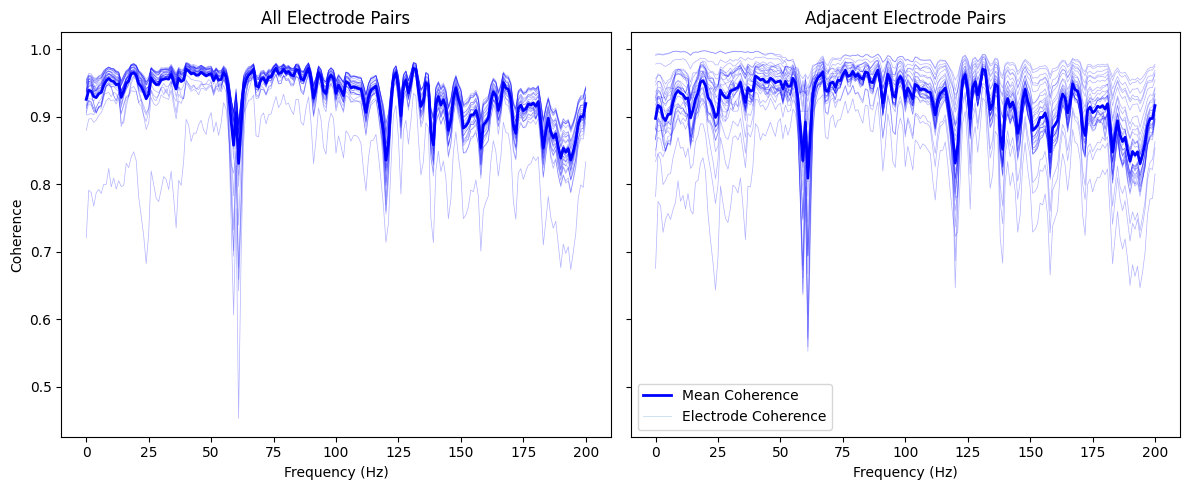

In [18]:
# Plot coherence (log y plot) (plot all connections and only adjacent connections in different subplots)

el_diff = np.abs(el_1 - el_2)
adjacent_mask = el_diff == 1

fig, axs = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

axs[0].set_title('All Electrode Pairs')
el_ids = np.unique(el_1)
for i in el_ids:
    mask = (el_1 == i) | (el_2 == i)
    el_coherence = coherence[mask]

    axs[0].plot(frequency, np.mean(el_coherence, axis=0), alpha=0.3, linewidth=0.5, color="blue")
axs[0].plot(frequency, np.mean(coherence, axis=0), linewidth=2, label='Mean Coherence', color="blue")
axs[0].plot([], [], alpha=0.3, linewidth=0.5, label='Electrode Coherence')
axs[0].set_xlabel('Frequency (Hz)')
axs[0].set_ylabel('Coherence')

axs[1].set_title('Adjacent Electrode Pairs')
for i in el_ids:
    mask = ((el_1 == i) | (el_2 == i)) & adjacent_mask
    el_coherence = coherence[mask]

    axs[1].plot(frequency, np.mean(el_coherence, axis=0), alpha=0.3, linewidth=0.5, color="blue")
axs[1].plot(frequency, np.mean(coherence[adjacent_mask], axis=0), linewidth=2, label='Mean Coherence', color="blue")
axs[1].plot([], [], alpha=0.3, linewidth=0.5, label='Electrode Coherence')
axs[1].set_xlabel('Frequency (Hz)')
axs[1].legend()

plt.tight_layout()
plt.show()


C:\Users\Organoid PC\AppData\Local\Temp\ipykernel_1804\148276999.py:36: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



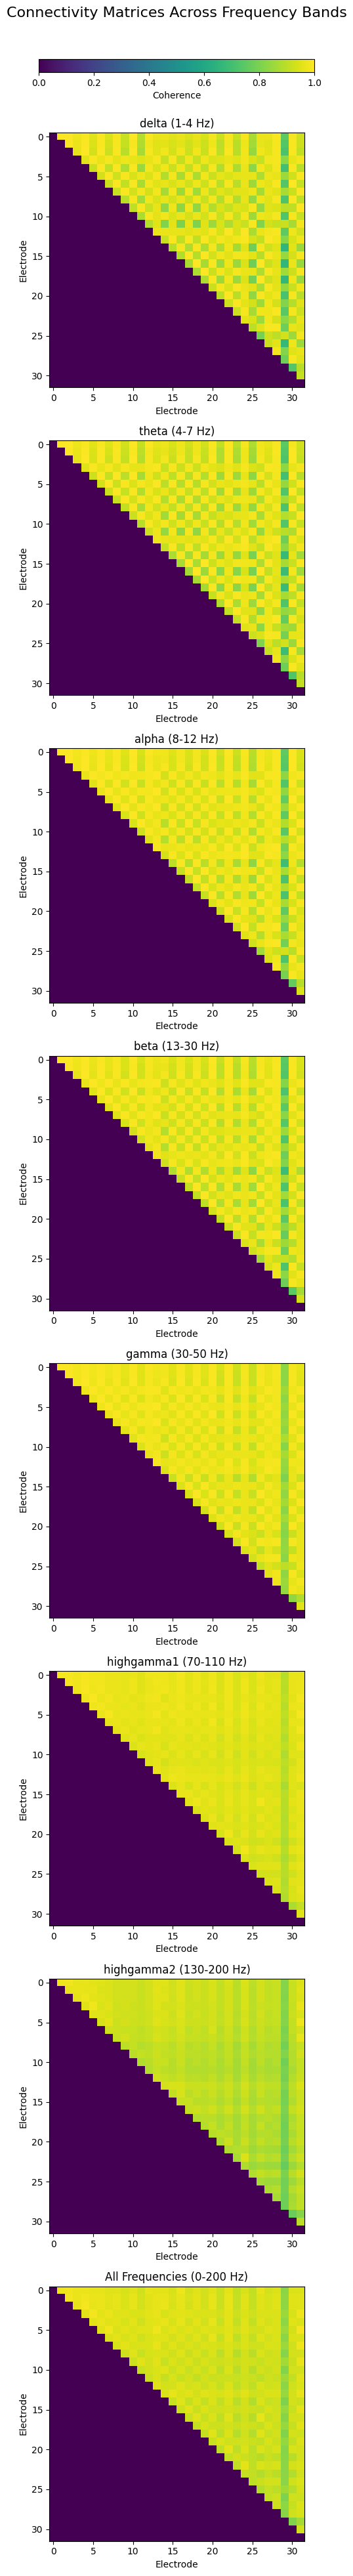

In [41]:
# Plot Connectivity Matrix at specific frequency bands
frequency_bands = analysis.SpectralBand.fetch(as_dict=True, order_by="lower_freq")
frequency_bands = dict((band_dict["band_name"], (band_dict["lower_freq"], band_dict["upper_freq"])) for band_dict in frequency_bands)
frequency_bands["All Frequencies"] = (frequency[0], frequency[-1])

# Get Frequency Band Data
band_data = {}
for band_name, (f_lower, f_upper) in frequency_bands.items():
    band_mask = (frequency >= f_lower) & (frequency <= f_upper)
    band_coherence = np.mean(coherence[:, band_mask], axis=1)

    # Create Connectivity Matrix
    n_electrodes = len(np.unique(np.concatenate((el_1, el_2))))
    connectivity_matrix = np.zeros((n_electrodes, n_electrodes))
    for i in range(len(el_1)):
        connectivity_matrix[el_1[i], el_2[i]] = band_coherence[i]

    band_data[band_name] = connectivity_matrix

# Plot Connectivity Matrices for each band
fig, ax = plt.subplots(len(frequency_bands), 1, figsize=(6, 5 * len(frequency_bands)))

for i, (band_name, connectivity_matrix) in enumerate(band_data.items()):
    im = ax[i].imshow(connectivity_matrix, vmin=0, vmax=1, cmap='viridis')
    ax[i].set_title(f"{band_name} ({int(frequency_bands[band_name][0])}-{int(frequency_bands[band_name][1])} Hz)")
    ax[i].set_xlabel('Electrode')
    ax[i].set_ylabel('Electrode')

# Add global colorbar (horizontal at top of figure)
cbar_ax = fig.add_axes([0.15, .955, 0.7, 0.005])  # [left, bottom, width, height]
cbar = fig.colorbar(im, cax=cbar_ax, orientation='horizontal')
cbar.set_label('Coherence')

plt.suptitle('Connectivity Matrices Across Frequency Bands', fontsize=16)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [ ]:
# 